In [ ]:
!pip install -q kagglehub

import kagglehub
import os
import shutil


print("Starting download...")
download_path = kagglehub.dataset_download("yangsangtai/tiny-genimage")

print("\nDataset downloaded to temporary cache:")
print(download_path)

TARGET_DIR = "/content/tiny_genimage"
if not os.path.exists(TARGET_DIR):
    shutil.copytree(download_path, TARGET_DIR)
    print(f"\nFiles moved to: {TARGET_DIR}")

print("\nGenerators found in dataset:")
!ls {TARGET_DIR}

Starting download...
Resuming download from 8158969856 bytes (186918689 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/yangsangtai/tiny-genimage/1.archive (8158969856/8345888545) bytes left.


100%|██████████| 7.77G/7.77G [00:15<00:00, 12.2MB/s]

Extracting files...



Dataset downloaded to temporary cache:
/root/.cache/kagglehub/datasets/yangsangtai/tiny-genimage/versions/1

Files moved to: /content/tiny_genimage

Generators found in dataset:
imagenet_ai_0419_biggan  imagenet_ai_0424_wukong  imagenet_midjourney
imagenet_ai_0419_vqdm	 imagenet_ai_0508_adm
imagenet_ai_0424_sdv5	 imagenet_glide


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
from torchvision import models

class bceLoss(nn.Module):
    def __init__(self):
        super(bceLoss, self).__init__()
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, preds, labels):
        return self.loss_fn(preds, labels)

class ResNet50_Baseline(nn.Module):
    def __init__(self):
        super(ResNet50_Baseline, self).__init__()
        self.backbone = models.resnet50(pretrained=True)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

def resnet50():
    return ResNet50_Baseline()

class BaselineOptions:
    def __init__(self):
        self.batch_size = 32
        self.input_size = 256
        self.lr = 1e-4
        self.epoch = 5
        self.save_path = './baseline_resnet50_genimage/'
        self.load = None
        self.gpu_id = '0'

opt = BaselineOptions()

if not os.path.exists(opt.save_path):
    os.makedirs(opt.save_path)
    print(f"Created baseline directory at: {opt.save_path}")

print("ResNet-50 Baseline and Configuration defined.")

Created baseline directory at: ./baseline_resnet50_genimage/
ResNet-50 Baseline and Configuration defined.


In [ ]:

import os
from torch.utils.data import ConcatDataset, DataLoader
from torchvision import datasets, transforms
import torch

# Define image transformations
IMAGE_SIZE = 256

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATA_ROOT = "/content/tiny_genimage"

all_subsets = [
    'imagenet_ai_0419_biggan', 'imagenet_ai_0419_vqdm',
    'imagenet_ai_0424_sdv5', 'imagenet_ai_0424_wukong',
    'imagenet_ai_0508_adm', 'imagenet_glide',
    'imagenet_midjourney'
]

train_datasets_list = []
val_full_list = []

print("Gathering ALL generator subsets...")
for folder in all_subsets:
    t_path = os.path.join(DATA_ROOT, folder, 'train')
    if os.path.exists(t_path):
        train_datasets_list.append(datasets.ImageFolder(t_path, transform=train_transforms))

    v_path = os.path.join(DATA_ROOT, folder, 'val')
    if os.path.exists(v_path):
        val_full_list.append(datasets.ImageFolder(v_path, transform=val_test_transforms))

    print(f"Loaded: {folder}")

super_train_dataset = ConcatDataset(train_datasets_list)
super_val_full_dataset = ConcatDataset(val_full_list)

TOTAL_VAL_IMAGES = len(super_val_full_dataset)
VAL_SIZE = int(0.5 * TOTAL_VAL_IMAGES)
TEST_SIZE = TOTAL_VAL_IMAGES - VAL_SIZE

val_dataset_split, test_dataset_split = torch.utils.data.random_split(
    super_val_full_dataset,
    [VAL_SIZE, TEST_SIZE],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(super_train_dataset, batch_size=opt.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)
final_test_loader = DataLoader(test_dataset_split, batch_size=opt.batch_size, shuffle=False, num_workers=2)

print(f"\nTotal Training Images (All Techs): {len(super_train_dataset)}")
print(f"Validation Set Size: {len(val_dataset_split)}")
print(f"Final Unbiased Test Set: {len(test_dataset_split)}")

Gathering ALL generator subsets...
Loaded: imagenet_ai_0419_biggan
Loaded: imagenet_ai_0419_vqdm
Loaded: imagenet_ai_0424_sdv5
Loaded: imagenet_ai_0424_wukong
Loaded: imagenet_ai_0508_adm
Loaded: imagenet_glide
Loaded: imagenet_midjourney

Total Training Images (All Techs): 28000
Validation Set Size: 3500
Final Unbiased Test Set: 3500


In [ ]:
import torch
import torch.nn as nn
from datetime import datetime

step = 0
best_epoch = 0
best_accu = 0

def train(train_loader, model, optimizer, epoch, save_path):
    model.train()
    global step
    epoch_step = 0
    loss_all = 0
    total_correct = 0
    total_images = 0

    print(f'\n--- ResNet-50 Baseline: Training Epoch {epoch:03d} ---')

    for i, (images, labels) in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float()

        preds = model(images)
        loss_fn = bceLoss().to(DEVICE)
        loss = loss_fn(preds, labels)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probabilities = torch.sigmoid(preds)
            predicted_labels = (probabilities > 0.5).float()
            total_correct += (predicted_labels == labels).sum().item()
            total_images += images.size(0)

        step += 1
        epoch_step += 1
        loss_all += loss.item()

        if i % 100 == 0:
            current_train_acc = total_correct / total_images
            print(f'Step [{i:04d}/{len(train_loader)}], Loss: {loss.item():.4f}, Train Acc: {current_train_acc:.4f}')

    print(f"Epoch {epoch:03d} Avg Loss: {loss_all/epoch_step:.4f}, Final Train Acc: {total_correct/total_images:.4f}")

def val(val_loader, model, epoch, save_path):
    model.eval()
    global best_epoch, best_accu
    total_correct = 0
    total_images = 0

    print(f'\n--- ResNet-50 Baseline: Validating Epoch {epoch:03d} ---')

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).float()

            res = model(images)
            probs = torch.sigmoid(res)
            preds = (probs > 0.5).float()

            total_correct += (preds == labels).sum().item()
            total_images += images.size(0)

    total_accu = total_correct / total_images
    print(f'Validation Accuracy: {total_accu:.4f}')

    if total_accu > best_accu:
        best_accu = total_accu
        best_epoch = epoch
        torch.save(model.state_dict(), os.path.join(save_path, 'ResNet50_best.pth'))
        print(f'New Baseline Best Model saved! Best Accu: {best_accu:.4f}')

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def poly_lr(optimizer, initial_lr, epoch, max_epochs, power=0.9):
    lr = initial_lr * (1 - epoch / max_epochs)**power
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    return lr

model = resnet50().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=opt.lr)

best_epoch = 0
best_accu = 0

for epoch in range(1, opt.epoch + 1):
    cur_lr = poly_lr(optimizer, opt.lr, epoch, opt.epoch)
    train(train_loader, model, optimizer, epoch, opt.save_path)
    val(val_loader, model, epoch, opt.save_path)

print(f"\nBaseline Training Complete. Best Validation Acc: {best_accu:.4f}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]



--- ResNet-50 Baseline: Training Epoch 001 ---
Step [0100/875], Loss: 0.3944, Train Acc: 0.7719
Step [0200/875], Loss: 0.3976, Train Acc: 0.8087
Step [0300/875], Loss: 0.3126, Train Acc: 0.8251
Step [0400/875], Loss: 0.4427, Train Acc: 0.8370
Step [0500/875], Loss: 0.3882, Train Acc: 0.8468
Step [0600/875], Loss: 0.2860, Train Acc: 0.8561
Step [0700/875], Loss: 0.3710, Train Acc: 0.8618
Step [0800/875], Loss: 0.3331, Train Acc: 0.8670
Epoch 001 Avg Loss: 0.3065, Final Train Acc: 0.8695

--- ResNet-50 Baseline: Validating Epoch 001 ---
Validation Accuracy: 0.8177
New Baseline Best Model saved! Best Accu: 0.8177

--- ResNet-50 Baseline: Training Epoch 002 ---
Step [0100/875], Loss: 0.1162, Train Acc: 0.9278
Step [0200/875], Loss: 0.1850, Train Acc: 0.9219
Step [0300/875], Loss: 0.2992, Train Acc: 0.9230
Step [0400/875], Loss: 0.1235, Train Acc: 0.9240
Step [0500/875], Loss: 0.1650, Train Acc: 0.9241
Step [0600/875], Loss: 0.1980, Train Acc: 0.9251
Step [0700/875], Loss: 0.1083, Train Ac

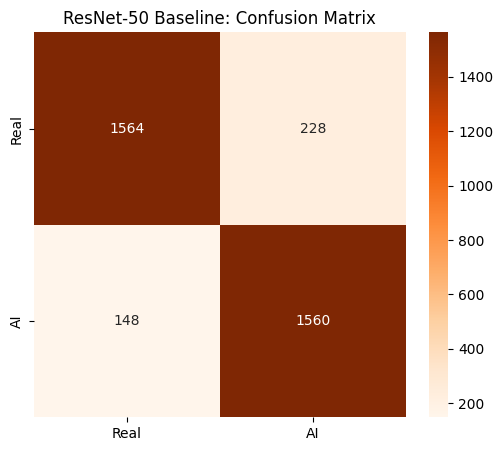


Baseline AUC Score: 0.9544
              precision    recall  f1-score   support

        Real       0.91      0.87      0.89      1792
          AI       0.87      0.91      0.89      1708

    accuracy                           0.89      3500
   macro avg       0.89      0.89      0.89      3500
weighted avg       0.89      0.89      0.89      3500



In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import os

def evaluate_baseline(model_path, test_loader, device):
    model = resnet50().to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_labels.extend(labels.numpy())
            all_preds.extend((probs > 0.5).astype(int))
            all_probs.extend(probs)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Real', 'AI'], yticklabels=['Real', 'AI'])
    plt.title('ResNet-50 Baseline: Confusion Matrix')
    plt.savefig('baseline_cm.png')
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    print(f"\nBaseline AUC Score: {auc(fpr, tpr):.4f}")
    print(classification_report(all_labels, all_preds, target_names=['Real', 'AI']))

evaluate_baseline(
    model_path=os.path.join(opt.save_path, 'ResNet50_best.pth'),
    test_loader=final_test_loader,
    device=DEVICE
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded weights from ./baseline_resnet50_genimage/ResNet50_best.pth
Running inference on test set...


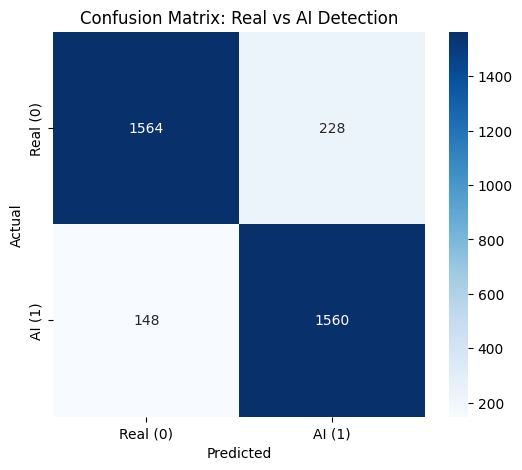

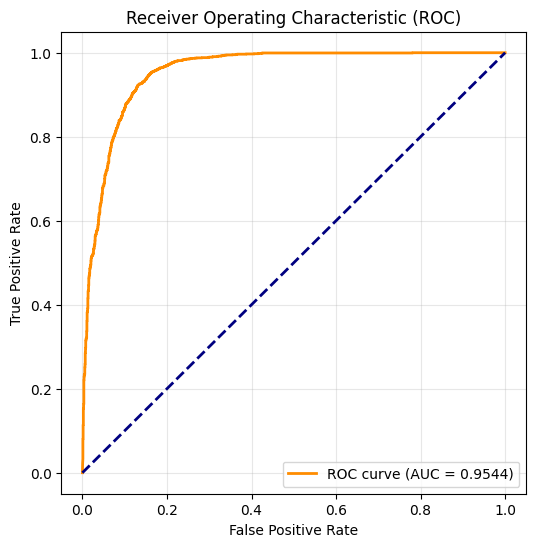

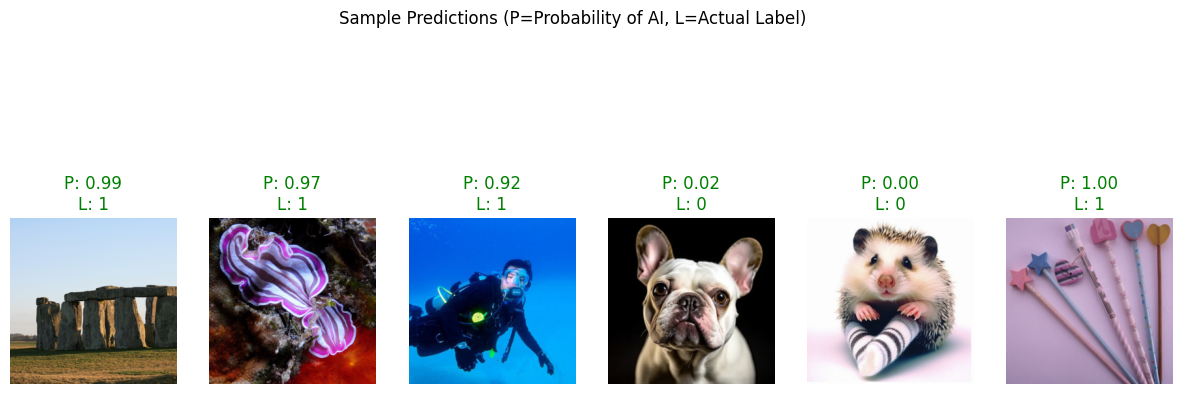


FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.91      0.87      0.89      1792
          AI       0.87      0.91      0.89      1708

    accuracy                           0.89      3500
   macro avg       0.89      0.89      0.89      3500
weighted avg       0.89      0.89      0.89      3500

Final Accuracy: 0.8926
AUC Score: 0.9544


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

def run_full_evaluation(model_path, test_loader, device):
    model = resnet50().to(device)
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Loaded weights from {model_path}")
    else:
        print(f"Error: {model_path} not found!")
        return

    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    print("Running inference on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real (0)', 'AI (1)'],
                yticklabels=['Real (0)', 'AI (1)'])
    plt.title('Confusion Matrix: Real vs AI Detection')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('confusion_matrix.png')
    plt.show()


    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('roc_curve.png')
    plt.show()

    plt.figure(figsize=(15, 6))
    images, labels = next(iter(test_loader))
    with torch.no_grad():
        sample_outputs = model(images[:6].to(device))
        sample_probs = torch.sigmoid(sample_outputs).cpu().numpy()

    for i in range(6):
        plt.subplot(1, 6, i+1)
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        color = 'green' if (sample_probs[i] > 0.5) == labels[i] else 'red'
        plt.title(f"P: {sample_probs[i]:.2f}\nL: {int(labels[i])}", color=color)
        plt.axis('off')
    plt.suptitle("Sample Predictions (P=Probability of AI, L=Actual Label)")
    plt.savefig('sample_predictions.png')
    plt.show()

    print("\n" + "="*40)
    print("FINAL CLASSIFICATION REPORT")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=['Real', 'AI']))
    print(f"Final Accuracy: {(np.array(all_labels) == np.array(all_preds)).mean():.4f}")
    print(f"AUC Score: {roc_auc:.4f}")


run_full_evaluation(
    model_path=os.path.join(opt.save_path, 'ResNet50_best.pth'),
    test_loader=final_test_loader,
    device=DEVICE
)